In [2]:
import pandas as pd
from pathlib import Path

project_root = Path("..")
df = pd.read_csv(project_root / "data" / "final_dataset.csv")
df.shape, df.columns

((1040564, 18),
 Index(['url', 'type', 'label', 'url_length', 'host_length', 'path_length',
        'num_digits', 'num_special', 'num_letters', 'num_dots', 'num_slashes',
        'entropy', 'keyword_count', 'digit_proportion', 'letter_proportion',
        'special_proportion', 'ccr_transition', 'avg_path_token_length'],
       dtype='object'))

## Define X and Y

In [ ]:
import numpy as np

y = df["label"].astype(int)

X = df.drop(columns=["label", "url", "type"], errors="ignore")

# keep only numeric features
X = X.select_dtypes(include=[np.number]).fillna(0.0)
X.shape, y.value_counts()

((1040564, 15),
 label
 0    773818
 1    266746
 Name: count, dtype: int64)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True

)

y_train.value_counts(), y_test.value_counts()

(label
 0    619054
 1    213397
 Name: count, dtype: int64,
 label
 0    154764
 1     53349
 Name: count, dtype: int64)

## SMOTE on training

In [ ]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

Before SMOTE:
 label
0    619054
1    213397
Name: count, dtype: int64

After SMOTE:
 label
0    619054
1    619054
Name: count, dtype: int64


## TRain Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train_sm, y_train_sm)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate Test

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, proba))

[[148595   6169]
 [  8162  45187]]
              precision    recall  f1-score   support

           0     0.9479    0.9601    0.9540    154764
           1     0.8799    0.8470    0.8631     53349

    accuracy                         0.9311    208113
   macro avg     0.9139    0.9036    0.9086    208113
weighted avg     0.9305    0.9311    0.9307    208113

ROC AUC: 0.969900462004658


## Test Confusion Matrix

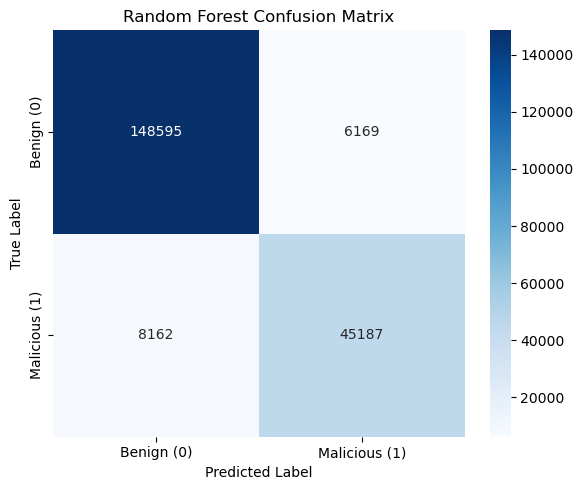

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

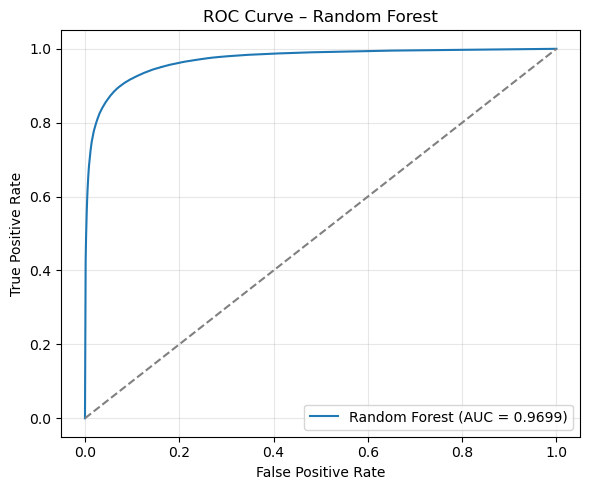

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate Train

In [12]:
# Train set evaluation
train_pred = rf.predict(X_train_sm)
train_proba = rf.predict_proba(X_train_sm)[:, 1]

print("TRAIN CONFUSION MATRIX")
print(confusion_matrix(y_train_sm, train_pred))
print(classification_report(y_train_sm, train_pred, digits=4))
print("Train ROC AUC:", roc_auc_score(y_train_sm, train_proba))

TRAIN CONFUSION MATRIX
[[616226   2828]
 [  7489 611565]]
              precision    recall  f1-score   support

           0     0.9880    0.9954    0.9917    619054
           1     0.9954    0.9879    0.9916    619054

    accuracy                         0.9917   1238108
   macro avg     0.9917    0.9917    0.9917   1238108
weighted avg     0.9917    0.9917    0.9917   1238108

Train ROC AUC: 0.9994885601686159


## Test Confusion Train

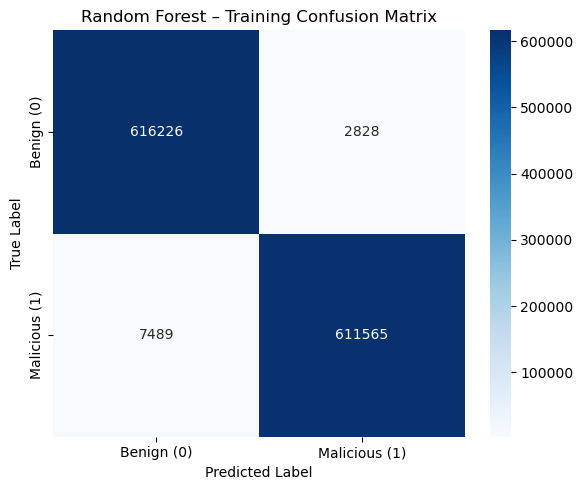

In [14]:
cm_train = confusion_matrix(y_train_sm, train_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest – Training Confusion Matrix")
plt.tight_layout()
plt.show()

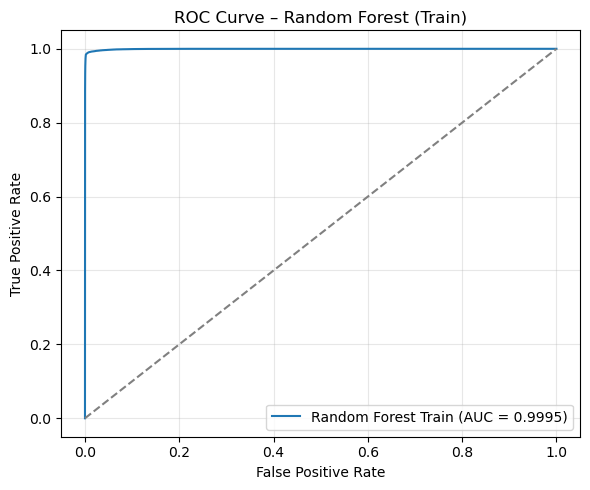

In [15]:
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_train_sm, train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_train,
    tpr_train,
    label=f"Random Forest Train (AUC = {roc_auc_train:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest (Train)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()